In [1]:
#imports
from google.cloud import bigquery
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick

In [2]:
 client = bigquery.Client(project="flb-rtl-dtl-bi")

### Definicion Campaña

In [3]:
campaing_name = "Fran Larrain"

In [4]:
fecha_inicio_str  = "2026-05-19"
fecha_fin_str     = "2026-05-24"

In [5]:
filter_column = "ID_ESTILO"     
filter_values = [883750108, 883750118, 883750123, 883750113, 883750159, 883750154, 883750128, 883750133]

In [6]:
url_navegacion = "collection/franlarrain" # https://www.falabella.com/falabella-cl/collection/munchlings

#### Piscina a comparar Lift:
- Vestuario  
- Digitales  
- Belleza  
- Calzado  
- Electro  
- Big Ticket  
- Hogar  

In [7]:
# para los lifts
comprative_pool = "Vestuario"

Comparativo para Perfil

In [8]:
filter_column_comp= "PROD_SUB_CAT_ID"
filter_values_comp=  ["J0410"]  # definir bien

comparative_name = "OUTERWEAR MUJER JOVEN"

-----

----

----

funcion auxiliar para armar el "IN"



  

In [9]:
def sql_literal(v):
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        return str(v)
    return "'" + str(v).replace("'", "''") + "'"

def build_in_filter(column, values):
    """Devuelve '1=1' si values está vacío, si no 'col IN (..)' con literales SQL."""
    if not values:
        return "1=1"
    values_sql = ", ".join(sql_literal(v) for v in values)
    return f"{column} IN ({values_sql})"

In [10]:
dynamic_filter      = build_in_filter(filter_column, filter_values)
dynamic_filter_comp = build_in_filter(filter_column_comp, filter_values_comp)

print(dynamic_filter)     
print(dynamic_filter_comp) 

ID_ESTILO IN (883750108, 883750118, 883750123, 883750113, 883750159, 883750154, 883750128, 883750133)
PROD_SUB_CAT_ID IN ('J0410')


### Transaccional [QR]

In [11]:

sql = f"""
DECLARE fecha_analisis_inicio DATE DEFAULT '{fecha_inicio_str}';
DECLARE fecha_analisis_fin    DATE DEFAULT '{fecha_fin_str}';

WITH base_transacciones AS (
  SELECT
    TRAN_DT AS fecha,

    CASE 
      WHEN data_source = 'CATALYST' THEN 'FCOM'
      WHEN STORE_NAME = 'VENTA A DISTANCIA' THEN 'FCOM'
      ELSE 'TIENDA'
    END AS canal,

    CONCAT(CAST(CUST_ID AS STRING), '-', CAST(TRAN_DT AS STRING), '-', STORE_NAME) AS id_visita,

    PROD_CAT_ID || "-" ||PROD_CAT_DESC             AS linea,
    PROD_SUB_CAT_ID || "-" || PROD_SUB_CAT_DESC    AS sublinea,
    PROD_SUB_CAT2_ID || "-" ||PROD_SUB_CAT2_DESC   AS clase,
    PROD_SUB_CAT3_ID || "-" ||PROD_SUB_CAT3_DESC   AS subclase,

    SUM(TRAN_TOTAL_AMT) AS venta,
    SUM(TRAN_QTY) AS unidades,

    prod_brand_id as marca,
    store_name,

  FROM `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified`

  WHERE TRAN_DT BETWEEN fecha_analisis_inicio AND fecha_analisis_fin
    AND PARTITION_DATE BETWEEN fecha_analisis_inicio AND fecha_analisis_fin
    AND VALID_PRODUCT_FLG = TRUE
     AND (STORE_F_FLG = TRUE OR STORE_STAND_ALONE_FLG = TRUE)
    AND TRAN_TYPE_DESC IN ('VENTA','FACTURA')
    AND BU_MODEL IN ('3P GSC','3P IMP','1P FALABELLA','3P SVL')
    AND ({dynamic_filter})

  GROUP BY ALL
)

SELECT
  fecha,
  canal,
  linea,
  sublinea,
  clase,
  subclase,
  marca,
  store_name,
  SUM(venta)     AS venta,
  SUM(unidades)  AS unidades,
  COUNT(DISTINCT id_visita) AS visitas
FROM base_transacciones
GROUP BY ALL
ORDER BY
  fecha, canal
"""


In [12]:
print(sql)


DECLARE fecha_analisis_inicio DATE DEFAULT '2026-05-19';
DECLARE fecha_analisis_fin    DATE DEFAULT '2026-05-24';

WITH base_transacciones AS (
  SELECT
    TRAN_DT AS fecha,

    CASE 
      WHEN data_source = 'CATALYST' THEN 'FCOM'
      WHEN STORE_NAME = 'VENTA A DISTANCIA' THEN 'FCOM'
      ELSE 'TIENDA'
    END AS canal,

    CONCAT(CAST(CUST_ID AS STRING), '-', CAST(TRAN_DT AS STRING), '-', STORE_NAME) AS id_visita,

    PROD_CAT_ID || "-" ||PROD_CAT_DESC             AS linea,
    PROD_SUB_CAT_ID || "-" || PROD_SUB_CAT_DESC    AS sublinea,
    PROD_SUB_CAT2_ID || "-" ||PROD_SUB_CAT2_DESC   AS clase,
    PROD_SUB_CAT3_ID || "-" ||PROD_SUB_CAT3_DESC   AS subclase,

    SUM(TRAN_TOTAL_AMT) AS venta,
    SUM(TRAN_QTY) AS unidades,

    prod_brand_id as marca,
    store_name,

  FROM `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified`

  WHERE TRAN_DT BETWEEN fecha_analisis_inicio AND fecha_analisis_fin
    AND PARTITION_DATE BETWEEN fecha_analisi

In [13]:
df = client.query(sql).to_dataframe()

#### KPIs Principales Venta

In [14]:
print("-----------------Venta Canal---------------")
df["venta"] = pd.to_numeric(df["venta"], errors="coerce")
venta_canal = (df.groupby("canal")["venta"].sum().div(1000000).round(1).astype(str) + " MM") 
venta_canal.name = None # para quitar el nombre

print(venta_canal.to_string())
print("-----------------Venta Total---------------")
print(f"{df['venta'].sum() / 1000000:,.1f} MM")

-----------------Venta Canal---------------
canal
FCOM      13.9 MM
TIENDA     5.6 MM
-----------------Venta Total---------------
19.5 MM


#### Graficos Trx

In [15]:
import pandas as pd

# Normalizar tipos
df["fecha"] = pd.to_datetime(df["fecha"])
df["canal"] = df["canal"].astype(str).str.upper()
df["venta"] = pd.to_numeric(df["venta"], errors="coerce").fillna(0)

# =========================
# Venta total por día
# =========================
df_venta_dia = (
    df.groupby("fecha", as_index=False)["venta"]
      .sum()
      .sort_values("fecha")
      .rename(columns={"venta": "venta_total"})
)

# =========================
# Venta diaria por canal
# =========================
df_venta_canal = (
    df.pivot_table(
        index="fecha",
        columns="canal",
        values="venta",
        aggfunc="sum"
    )
    .fillna(0)
    .reset_index()
)

df_venta_canal = df_venta_canal.sort_values("fecha")

# Si alguna columna no existe, la creamos en 0
for col in ["TIENDA", "FCOM"]:
    if col not in df_venta_canal.columns:
        df_venta_canal[col] = 0

In [16]:
df_venta_canal

canal,fecha,FCOM,TIENDA
0,2026-05-19,2974608.0,1153842.0
1,2026-05-20,6780124.0,1952730.0
2,2026-05-21,4120056.0,2524642.0


In [17]:
df_venta_canal.to_csv("J02.csv", index=False)
df_venta_canal["FCOM"].sum() + df_venta_canal["TIENDA"].sum()


np.float64(19506002.0)

In [18]:
import matplotlib.pyplot as plt

FALABELLA_GREEN = "#1E7F5C"
STACK_TIENDA = "#2E7D32"
STACK_FCOM = "#A5D6A7"

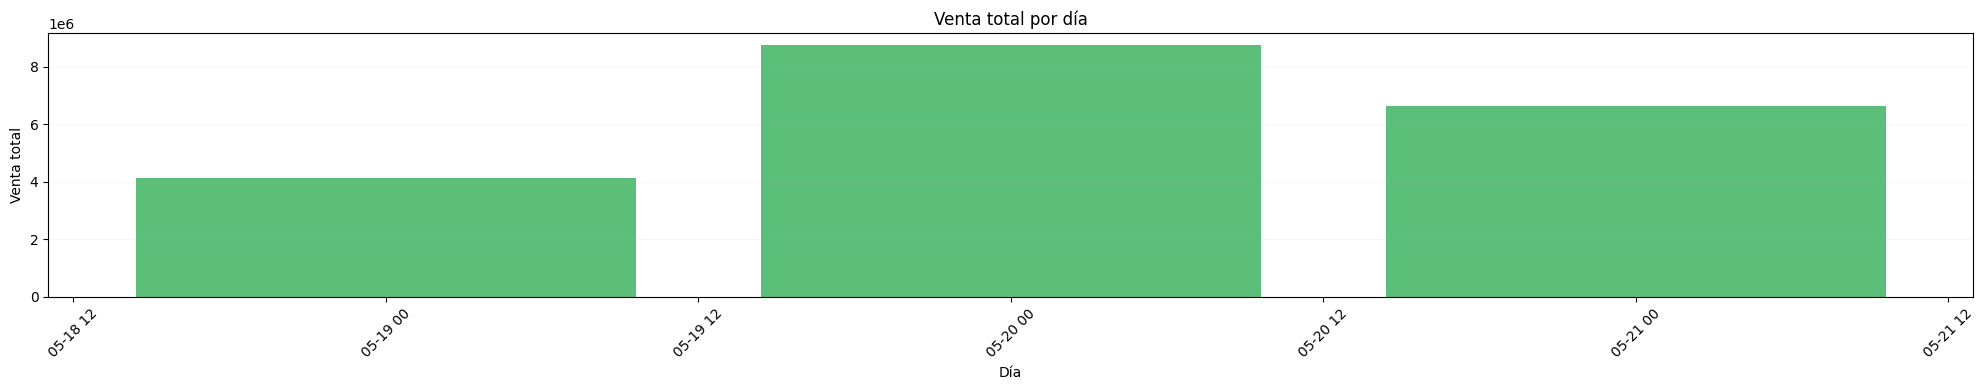

In [19]:
plt.figure(figsize=(20, 4))
GREEN = "#5BBF7A"
plt.bar(
    df_venta_dia["fecha"],
    df_venta_dia["venta_total"],
    color=GREEN
)

plt.xlabel("Día")
plt.ylabel("Venta total")
plt.title("Venta total por día")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.1)
plt.tight_layout()
plt.show()

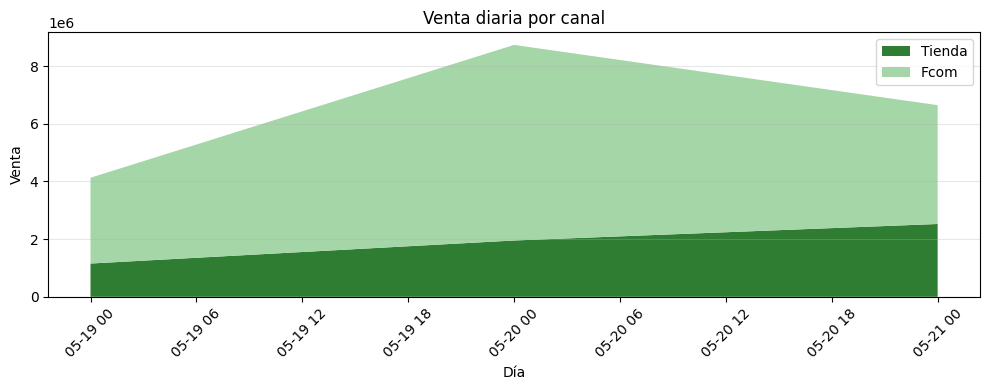

In [20]:
plt.figure(figsize=(10, 4))

plt.stackplot(
    df_venta_canal["fecha"],
    df_venta_canal["TIENDA"],
    df_venta_canal["FCOM"],
    labels=["Tienda", "Fcom"],
    colors=[STACK_TIENDA, STACK_FCOM]
)

plt.xlabel("Día")
plt.ylabel("Venta")
plt.title("Venta diaria por canal")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

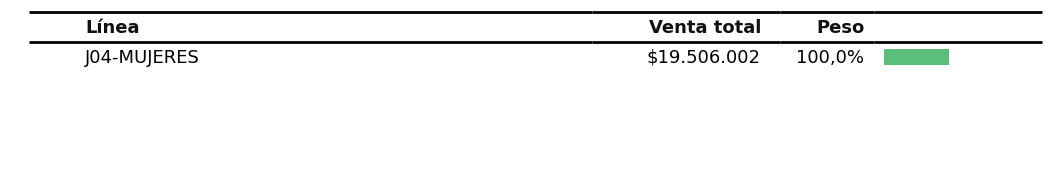

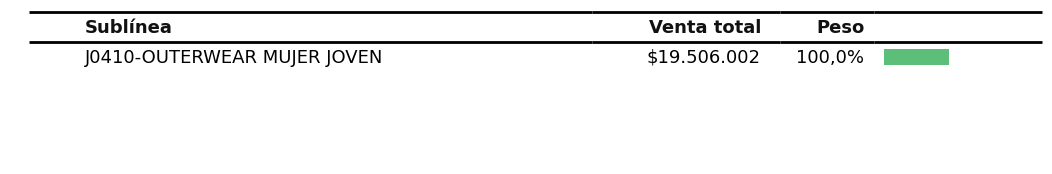

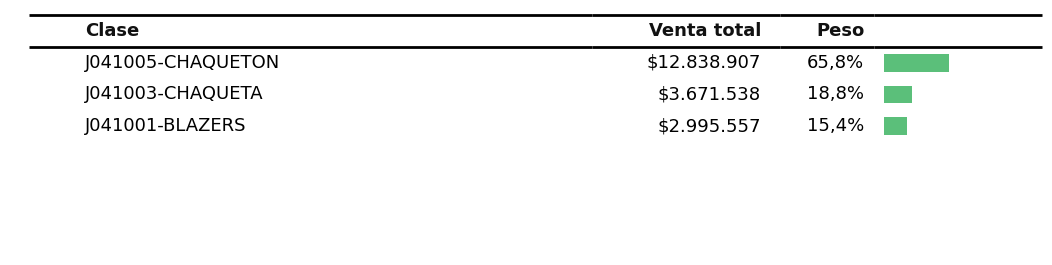

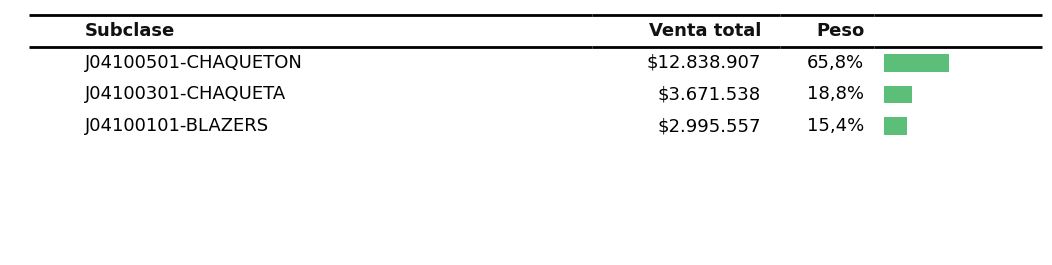

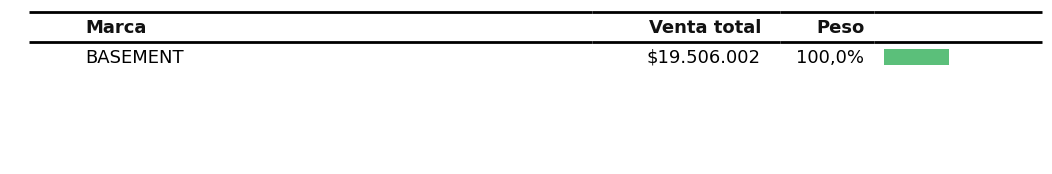

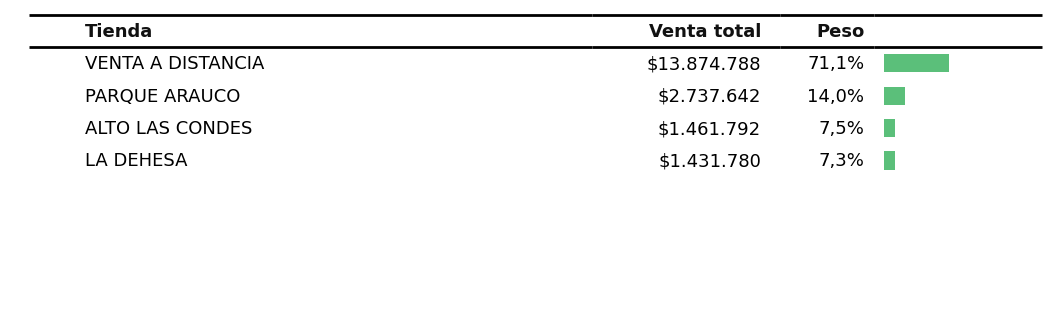

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ====== Setup ======
top_n = 10
WEIGHT_BAR = "#5BBF7A"
TEXT_COLOR = "#111111"

df["venta"] = pd.to_numeric(df["venta"], errors="coerce").fillna(0)

def format_money_cl(x: float) -> str:
    return "$" + f"{x:,.0f}".replace(",", ".")

def format_pct_cl(p: float) -> str:
    return f"{p*100:.1f}%".replace(".", ",")

def top_table(df, group_col, top_n=10):
    g = df.groupby(group_col, as_index=False)["venta"].sum().sort_values("venta", ascending=False).head(top_n).reset_index(drop=True)
    total = g["venta"].sum() if g["venta"].sum() != 0 else 1.0
    g["peso"] = g["venta"] / total
    g = g.rename(columns={group_col: "name", "venta": "value"})
    g["value_str"] = g["value"].map(lambda x: format_money_cl(float(x)))
    g["peso_str"] = g["peso"].map(format_pct_cl)
    return g[["name", "value_str", "peso_str", "peso"]]

def render_weight_table(df_tbl, left_header, figsize=(10.5, 2.6), dpi=220):
    col_widths = (0.60, 0.20, 0.10, 0.18)
    headers = [left_header, "Venta total", "Peso", ""]
    t = df_tbl.reset_index(drop=True).copy()
    t["bar"] = ""

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=t[["name", "value_str", "peso_str", "bar"]].values,
        colLabels=headers,
        colLoc="left",
        cellLoc="left",
        loc="upper left",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(13)
    table.scale(1, 1.65)

    n_rows = len(t) + 1
    for r in range(n_rows):
        for c, w in enumerate(col_widths):
            table[(r, c)].set_width(w)

    for (r, c), cell in table.get_celld().items():
        cell.set_facecolor("white")
        if r == 0:
            cell.set_text_props(weight="bold", color=TEXT_COLOR)
            cell.visible_edges = "TB"
            cell.set_linewidth(2.0)
        else:
            cell.visible_edges = ""
            cell.set_linewidth(0)

        if c == 0:
            cell.get_text().set_ha("left")
        elif c in (1, 2):
            cell.get_text().set_ha("right")
        else:
            cell.get_text().set_ha("left")

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    for i in range(len(t)):
        r = i + 1
        w = max(0.0, min(1.0, float(t.loc[i, "peso"])))
        bar_cell = table[(r, 3)]
        bbox = bar_cell.get_window_extent(renderer)
        inv = ax.transAxes.inverted()
        (x0, y0) = inv.transform((bbox.x0, bbox.y0))
        (x1, y1) = inv.transform((bbox.x1, bbox.y1))

        pad_x = (x1 - x0) * 0.06
        pad_y = (y1 - y0) * 0.22
        full_w = (x1 - x0) - 2 * pad_x
        full_h = (y1 - y0) - 2 * pad_y

        ax.add_patch(plt.Rectangle(
            (x0 + pad_x, y0 + pad_y),
            full_w * w,
            full_h,
            transform=ax.transAxes,
            facecolor=WEIGHT_BAR,
            edgecolor="none",
        ))
        bar_cell.get_text().set_text("")

    plt.tight_layout()
    plt.show()

# ====== 4 tablas: línea / sublínea / clase / subclase ======
for col, header in [("linea", "Línea"), ("sublinea", "Sublínea"), ("clase", "Clase"), ("subclase", "Subclase"), ("marca", "Marca"),("store_name","Tienda")]:
    tbl = top_table(df, col, top_n=top_n)
    render_weight_table(tbl, header, figsize=(10.5, 0.45*len(tbl) + 1.4))

### Perfil [QR]

In [22]:
sql_perfil = f"""

# Perfil de clientes - canal

DECLARE max_partition DATE;

DECLARE fecha_analisis_inicio DATE DEFAULT '{fecha_inicio_str}';
DECLARE fecha_analisis_fin    DATE DEFAULT '{fecha_fin_str}';
SET max_partition = (
  SELECT MAX(partition_date)
  FROM `falabella-rtl-segmentation-ai.sia_10_mkt_processes.customer_lifecycle`
  WHERE partition_date <  fecha_analisis_fin
);
 
 
with

SOCIODEMO AS
(
   SELECT
  sd.CUST_ID,
  sd.ESTADO,
  sd.cust_gender,
  sd.COMUNA_DEF,
  sd.CUST_DOB,
  case
  when CUST_GSE in ("AB","C1","C1A","C1B") THEN "ABC1"
  when CUST_GSE in ("C2") THEN "C2"
  when CUST_GSE in ("C3") THEN "C3"
  when CUST_GSE in ("D") THEN "D"
  when CUST_GSE in ("E") THEN "E"
  ELSE "GSE NO ID" END AS GSE,
  sd.ZONA,
  REGION_DEF,
  max(sd.CUST_AGE) AS edad_clte
  FROM `falabella-rtl-segmentation-ai.sia_10_mkt_processes.customer_lifecycle` sd
  where DATE(PARTITION_DATE) = max_partition
  GROUP BY ALL
)
 
 
,NUEVOS_FALABELLA AS
(
  SELECT
   a.CUST_RULE_ID,
  sum(TRAN_TOTAL_AMT) as venta,
  count(distinct a.CUST_RULE_ID||TRAN_DT||STORE_NAME) as visitas
   FROM `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified` a

  WHERE
  a.TRAN_DT  between DATE_SUB(fecha_analisis_inicio, INTERVAL 365 DAY) and DATE_SUB(fecha_analisis_inicio, INTERVAL 1 DAY)
  and a.PARTITION_DATE between DATE_SUB(fecha_analisis_inicio, INTERVAL 365 DAY) and DATE_SUB(fecha_analisis_inicio, INTERVAL 1 DAY)
   AND VALID_PRODUCT_FLG = TRUE
    AND STORE_F_FLG = TRUE
    AND INVALID_CUSTOMER_FLG = FALSE
    AND TRAN_TYPE_DESC IN ('VENTA','FACTURA','CAMBIO','DEVOLUCION')
    AND BU_MODEL IN ('3P GSC','3P IMP','1P FALABELLA','3P SVL')
   GROUP BY ALL
)

,CLIENTES_F AS
(
  SELECT
   a.CUST_RULE_ID,
  sum(TRAN_TOTAL_AMT) as venta,
  count(distinct a.CUST_RULE_ID||TRAN_DT||STORE_NAME) as visitas
   FROM `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified` a

  WHERE
  a.TRAN_DT  between DATE_SUB(fecha_analisis_inicio, INTERVAL 365 DAY) and DATE_SUB(fecha_analisis_inicio, INTERVAL 1 DAY)
  and a.PARTITION_DATE between DATE_SUB(fecha_analisis_inicio, INTERVAL 365 DAY) and DATE_SUB(fecha_analisis_inicio, INTERVAL 1 DAY)
   AND VALID_PRODUCT_FLG = TRUE
    AND STORE_F_FLG = TRUE
    AND INVALID_CUSTOMER_FLG = FALSE
    AND TRAN_TYPE_DESC IN ('VENTA','FACTURA','CAMBIO','DEVOLUCION')
    AND BU_MODEL IN ('3P GSC','3P IMP','1P FALABELLA','3P SVL')
   GROUP BY ALL
   HAVING venta > 620000 AND visitas > 6
)
 
 
, base_transacciones as(
select

ve.CUST_RULE_ID,
  sd.cust_gender,
  sd.COMUNA_DEF,
  sd.GSE,
  sd.ZONA,
  sd.edad_clte,

case when x.CUST_RULE_ID is not null then 0 else 1 end as ind_nuevo_fal,
case when cf.CUST_RULE_ID is not null then 1 else 0 end as ind_clte_f,

CASE
  WHEN ONLINE_FLG = TRUE THEN 'FCOM'
  ELSE 'TIENDA'
END AS tipo_tienda,

TRAN_DT,

ve.CUST_RULE_ID||TRAN_DT||STORE_NAME as id_visita,

PROD_CAT_ID as id_linea,
PROD_SUB_CAT_ID as id_sublinea,
PROD_SUB_CAT2_ID as id_clase,
PROD_SUB_CAT3_ID as id_subclase,

PROD_CAT_DESC as desc_linea,
PROD_SUB_CAT_DESC as desc_sublinea,
PROD_SUB_CAT2_DESC as desc_clase,
PROD_SUB_CAT3_DESC as desc_subclase,

PROD_F_CAT_ID as id_linea_f,
PROD_F_SUB_CAT_ID as id_sublinea_f,
PROD_F_SUB_CAT2_ID as id_clase_f,
PROD_F_SUB_CAT3_ID as id_subclase_f,

PROD_F_CAT_DESC as desc_linea_f,
PROD_F_SUB_CAT_DESC as desc_sublinea_f,
PROD_F_SUB_CAT2_DESC as desc_clase_f,
PROD_F_SUB_CAT3_DESC as desc_subclase_f,


SUM(TRAN_TOTAL_AMT) AS venta,
SUM(TRAN_QTY) AS unidades, 

CASE WHEN ({dynamic_filter}) THEN 1 ELSE 0 END AS ind_cam, --> hacerlo dinamico

CASE WHEN ({dynamic_filter_comp}) AND {dynamic_filter.replace("IN", "NOT IN")} THEN 1 ELSE 0 END AS ind_comp --> hacerlo dinamico


 
from `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified` ve
  LEFT JOIN SOCIODEMO sd ON ve.CUST_RULE_ID = sd.CUST_ID
  LEFT JOIN nuevos_falabella x ON ve.CUST_RULE_ID = x.CUST_RULE_ID
  LEFT JOIN CLIENTES_F cf ON ve.CUST_RULE_ID = cf.CUST_RULE_ID

WHERE
TRAN_DT between fecha_analisis_inicio and fecha_analisis_fin
  and PARTITION_DATE between fecha_analisis_inicio and fecha_analisis_fin
   AND VALID_PRODUCT_FLG = TRUE
    AND (STORE_F_FLG = TRUE OR STORE_STAND_ALONE_FLG = TRUE)
    AND INVALID_CUSTOMER_FLG = FALSE
    AND TRAN_TYPE_DESC IN ('VENTA','FACTURA')
    AND BU_MODEL IN ('3P GSC','3P IMP','1P FALABELLA','3P SVL')
 
group by all
)


, tipo_cliente as (
  select 
  CUST_RULE_ID,
  max(case when  tipo_tienda = 'TIENDA' then 1 else 0 end) as ind_tienda,
  max(case when tipo_tienda = 'FCOM' then 1 else 0 end) as ind_fcom,
  max(ind_cam) as ind_cam,
  max(ind_comp) as ind_comp
  from base_transacciones
  group by 1
)

/*
,hijos as (
SELECT
cust_id as cust_rule_id,
if(no_of_children >0,true,false) as ind_hijos,
FROM `tc-sc-bi-bigdata-cdl-prod.acc_fal_cl_cdp_prod.btd_ebim_customers_unify`
where cust_id is not null
group by all
order by 1 asc
)
*/


, metricas as (
SELECT
"campaña" as cat,
count(distinct b.CUST_RULE_ID) as clientes,
count(distinct case when cust_gender = 'F' then b.CUST_RULE_ID else null end) as cltes_Mujeres,
count(distinct case when cust_gender = 'M' then b.CUST_RULE_ID else null end) as cltes_Hombres,
count(distinct case when cust_gender in ('M','F') then b.CUST_RULE_ID else null end) as cltes_con_genero,
count(distinct case when edad_clte >=18 and edad_clte <=25 then b.CUST_RULE_ID else null end) as cltes_18_25,
count(distinct case when edad_clte >25 and edad_clte <=35 then b.CUST_RULE_ID else null end) as cltes_25_35,
count(distinct case when edad_clte >35 and edad_clte <=45 then b.CUST_RULE_ID else null end) as cltes_35_45,
count(distinct case when edad_clte >45 and edad_clte <=55 then b.CUST_RULE_ID else null end) as cltes_45_55,
count(distinct case when edad_clte >55 and edad_clte <=99 then b.CUST_RULE_ID else null end) as cltes_55_99,
count(distinct case when edad_clte between 18 and 99 then b.CUST_RULE_ID else null end) as cltes_con_edad,
count(DISTINCT CASE WHEN ZONA = "NORTE" THEN b.CUST_RULE_ID else null END) AS cltes_norte,
count(DISTINCT CASE WHEN ZONA = "SUR" THEN b.CUST_RULE_ID else null END) AS cltes_sur,
count(DISTINCT CASE WHEN ZONA = "RM PONIENTE" THEN b.CUST_RULE_ID else null END) AS cltes_poniente,
count(DISTINCT CASE WHEN ZONA = "RM ORIENTE" THEN b.CUST_RULE_ID else null END) AS cltes_oriente,
count(DISTINCT CASE WHEN ZONA in ('NORTE','SUR','RM PONIENTE','RM ORIENTE') THEN b.CUST_RULE_ID else null END) AS cltes_con_zona,
count(DISTINCT CASE WHEN GSE = "ABC1" THEN b.CUST_RULE_ID else null END) AS cltes_ABC1,
count(DISTINCT CASE WHEN GSE = "C2" THEN b.CUST_RULE_ID else null END) AS cltes_C2,
count(DISTINCT CASE WHEN GSE = "C3" THEN b.CUST_RULE_ID else null END) AS cltes_C3,
count(DISTINCT CASE WHEN GSE = "D" THEN b.CUST_RULE_ID else null END) AS cltes_D,
count(DISTINCT CASE WHEN GSE = "E" THEN b.CUST_RULE_ID else null END) AS cltes_E,
count(DISTINCT CASE WHEN GSE in ('ABC1','C2','C3','D','E') THEN b.CUST_RULE_ID else null END) AS cltes_con_gse,
count(DISTINCT CASE WHEN ind_nuevo_fal = 1 THEN b.CUST_RULE_ID else null END) AS cltes_nuevos_fal,
count(DISTINCT CASE WHEN ind_nuevo_fal = 1 and (edad_clte >=18 and edad_clte <=25) THEN b.CUST_RULE_ID else null END) AS cltes_jovenes_nuevos_fal,
count(distinct case when ind_clte_f = 1 THEN b.CUST_RULE_ID else null END) AS cltes_f,
sum(venta) as venta,
count(distinct id_visita) as visitas,
sum(unidades) as unidades,
--count(distinct if(ind_hijos is TRUE,b.cust_rule_id,null)) as cltes_con_hijos

FROM
base_transacciones b
--left join hijos using(cust_rule_id)
where 
ind_cam  = 1

union all

SELECT
"comparativo" as cat,
count(distinct b.CUST_RULE_ID) as clientes,
count(distinct case when cust_gender = 'F' then b.CUST_RULE_ID else null end) as cltes_Mujeres,
count(distinct case when cust_gender = 'M' then b.CUST_RULE_ID else null end) as cltes_Hombres,
count(distinct case when cust_gender in ('M','F') then b.CUST_RULE_ID else null end) as cltes_con_genero,
count(distinct case when edad_clte >=18 and edad_clte <=25 then b.CUST_RULE_ID else null end) as cltes_18_25,
count(distinct case when edad_clte >25 and edad_clte <=35 then b.CUST_RULE_ID else null end) as cltes_25_35,
count(distinct case when edad_clte >35 and edad_clte <=45 then b.CUST_RULE_ID else null end) as cltes_35_45,
count(distinct case when edad_clte >45 and edad_clte <=55 then b.CUST_RULE_ID else null end) as cltes_45_55,
count(distinct case when edad_clte >55 and edad_clte <=99 then b.CUST_RULE_ID else null end) as cltes_55_99,
count(distinct case when edad_clte between 18 and 99 then b.CUST_RULE_ID else null end) as cltes_con_edad,
count(DISTINCT CASE WHEN ZONA = "NORTE" THEN b.CUST_RULE_ID else null END) AS cltes_norte,
count(DISTINCT CASE WHEN ZONA = "SUR" THEN b.CUST_RULE_ID else null END) AS cltes_sur,
count(DISTINCT CASE WHEN ZONA = "RM PONIENTE" THEN b.CUST_RULE_ID else null END) AS cltes_poniente,
count(DISTINCT CASE WHEN ZONA = "RM ORIENTE" THEN b.CUST_RULE_ID else null END) AS cltes_oriente,
count(DISTINCT CASE WHEN ZONA in ('NORTE','SUR','RM PONIENTE','RM ORIENTE') THEN b.CUST_RULE_ID else null END) AS cltes_con_zona,
count(DISTINCT CASE WHEN GSE = "ABC1" THEN b.CUST_RULE_ID else null END) AS cltes_ABC1,
count(DISTINCT CASE WHEN GSE = "C2" THEN b.CUST_RULE_ID else null END) AS cltes_C2,
count(DISTINCT CASE WHEN GSE = "C3" THEN b.CUST_RULE_ID else null END) AS cltes_C3,
count(DISTINCT CASE WHEN GSE = "D" THEN b.CUST_RULE_ID else null END) AS cltes_D,
count(DISTINCT CASE WHEN GSE = "E" THEN b.CUST_RULE_ID else null END) AS cltes_E,
count(DISTINCT CASE WHEN GSE in ('ABC1','C2','C3','D','E') THEN b.CUST_RULE_ID else null END) AS cltes_con_gse,
count(DISTINCT CASE WHEN ind_nuevo_fal = 1 THEN b.CUST_RULE_ID else null END) AS cltes_nuevos_fal,
count(DISTINCT CASE WHEN ind_nuevo_fal = 1 and (edad_clte >=18 and edad_clte <=25) THEN b.CUST_RULE_ID else null END) AS cltes_jovenes_nuevos_fal,
count(distinct case when ind_clte_f = 1 THEN b.CUST_RULE_ID else null END) AS cltes_f,
sum(venta) as venta,
count(distinct id_visita) as visitas,
sum(unidades) as unidades,
--count(distinct if(ind_hijos is TRUE,b.cust_rule_id,null)) as cltes_con_hijos

FROM
base_transacciones b
--left join hijos using(cust_rule_id)
where 
ind_comp  = 1

GROUP BY ALL)


SELECT
  cat,
  clientes,
  SAFE_DIVIDE(venta,clientes) as Gasto_cliente,
  SAFE_DIVIDE(visitas,clientes) as Freq_compra,
  SAFE_DIVIDE(venta,visitas) as ticket_promedio,

  SAFE_DIVIDE(cltes_Mujeres,cltes_con_genero) as Mujeres,
  SAFE_DIVIDE(cltes_Hombres,cltes_con_genero) as Hombres,

  SAFE_DIVIDE(cltes_18_25,cltes_con_edad) AS cltes_18_25,
  SAFE_DIVIDE(cltes_25_35,cltes_con_edad) AS cltes_25_35,
  SAFE_DIVIDE(cltes_35_45,cltes_con_edad) AS cltes_35_45,
  SAFE_DIVIDE(cltes_45_55,cltes_con_edad) AS cltes_45_55,
  SAFE_DIVIDE(cltes_55_99,cltes_con_edad) AS cltes_55_99,

  SAFE_DIVIDE(cltes_norte,cltes_con_zona) AS cltes_norte,
  SAFE_DIVIDE(cltes_sur,cltes_con_zona) AS cltes_sur,
  SAFE_DIVIDE(cltes_poniente,cltes_con_zona) AS cltes_poniente,
  SAFE_DIVIDE(cltes_oriente,cltes_con_zona) AS cltes_oriente,

  SAFE_DIVIDE(cltes_ABC1,cltes_con_gse) AS cltes_ABC1,
  SAFE_DIVIDE(cltes_C2,cltes_con_gse) AS cltes_C2,
  SAFE_DIVIDE(cltes_C3,cltes_con_gse) AS cltes_C3,
  SAFE_DIVIDE(cltes_D,cltes_con_gse) AS cltes_D,
  SAFE_DIVIDE(cltes_E,cltes_con_gse) AS cltes_E,

  SAFE_DIVIDE(cltes_f,clientes) as cltes_f,
  SAFE_DIVIDE(cltes_nuevos_fal,clientes) as cltes_nuevos_fal,

  --SAFE_DIVIDE(cltes_con_hijos,clientes) as cltes_hijos,


FROM
  metricas
"""


In [23]:
client = bigquery.Client(project="flb-rtl-dtl-bi")  # usa tu proyecto
df_perfil = client.query(sql_perfil).to_dataframe()

#### KPIs Principales Clientes

In [24]:

print("-----------------Clientes Total---------------")
print(f"{df_perfil['clientes'].sum()}")

print("-----------------Clientes Jovenes ------------")
print(f"{(df_perfil['cltes_18_25'].sum() * 100).round(1)}%")

print("-----------------Clientes F ------------------")
print(f"{(df_perfil['cltes_f'].sum() * 100).round(1)}%")

-----------------Clientes Total---------------
6351
-----------------Clientes Jovenes ------------
9.4%
-----------------Clientes F ------------------
127.4%


In [25]:
df_perfil.head(10)

,cat,clientes,Gasto_cliente,Freq_compra,ticket_promedio,Mujeres,Hombres,cltes_18_25,cltes_25_35,cltes_35_45,...,cltes_sur,cltes_poniente,cltes_oriente,cltes_ABC1,cltes_C2,cltes_C3,cltes_D,cltes_E,cltes_f,cltes_nuevos_fal
0,campaña,189,99397.365079365,1.021164,97337.316062176,0.930851,0.069149,0.031746,0.190476,0.433862,...,0.138298,0.159574,0.648936,0.601064,0.180851,0.085106,0.127660,0.005319,0.798942,0.021164
1,comparativo,6162,42592.621226874,1.010062,42168.337403599,0.875742,0.124258,0.061822,0.231667,0.253699,...,0.307420,0.310954,0.201582,0.297116,0.156439,0.245137,0.242119,0.059188,0.475333,0.037326


#### Graficos Perfil

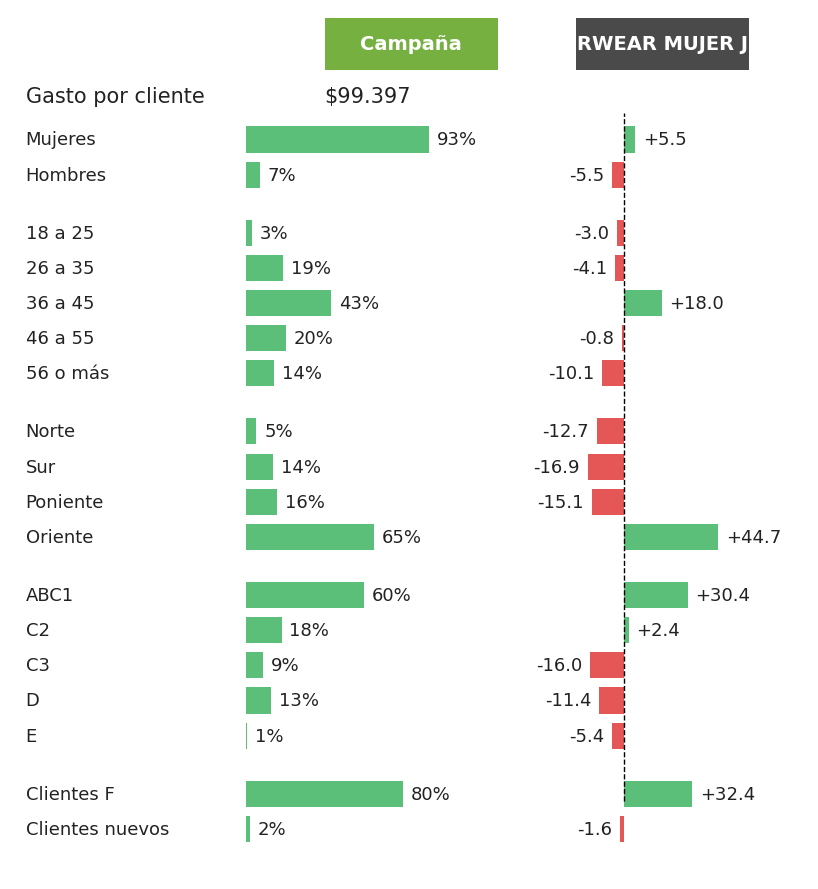

In [26]:
# -------------------------
# 1) Tomar filas campaña / comparativo
# -------------------------
camp = df_perfil[df_perfil["cat"].str.lower().str.contains("camp")].iloc[0]
comp = df_perfil[df_perfil["cat"].str.lower().str.contains("comp")].iloc[0]

# -------------------------
# 2) Estilos + helpers
# -------------------------
GREEN = "#5BBF7A"
RED   = "#E45756"
HEADER_GREEN = "#76B041"
HEADER_GRAY  = "#4A4A4A"
TEXT  = "#222222"

def to_float(x, default=0.0):
    try:
        x = float(x)
        if x != x:  # NaN
            return default
        return x
    except:
        return default

def clamp01(x):
    x = to_float(x, 0.0)
    return max(0.0, min(1.0, x))

def pct(x):
    return f"{clamp01(x)*100:.0f}%"

def money(x):
    return "$" + f"{to_float(x):,.0f}".replace(",", ".")

# -------------------------
# 3) Filas (None = separador)
# -------------------------
rows = [
    ("Mujeres", "Mujeres"), ("Hombres", "Hombres"), None,
    ("18 a 25", "cltes_18_25"), ("26 a 35", "cltes_25_35"), ("36 a 45", "cltes_35_45"),
    ("46 a 55", "cltes_45_55"), ("56 o más", "cltes_55_99"), None,
    ("Norte", "cltes_norte"), ("Sur", "cltes_sur"), ("Poniente", "cltes_poniente"), ("Oriente", "cltes_oriente"), None,
    ("ABC1", "cltes_ABC1"), ("C2", "cltes_C2"), ("C3", "cltes_C3"), ("D", "cltes_D"), ("E", "cltes_E"), None,
    ("Clientes F", "cltes_f"), ("Clientes nuevos", "cltes_nuevos_fal"),
]

# -------------------------
# 4) Escala delta pp automática
# -------------------------
deltas = []
for item in rows:
    if item is None:
        continue
    _, col = item
    deltas.append((to_float(camp.get(col, 0)) - to_float(comp.get(col, 0))) * 100)

max_delta = max(1.0, max(abs(x) for x in deltas))

# -------------------------
# 5) Función para dibujar fila
#    - % pegado al final REAL de la barra campaña
#    - delta pp con TEXTO pegado al final REAL de la barra delta (como pediste)
# -------------------------
def draw_row(ax, y, label, pct_camp, delta_pp,
             x_label=0.02,
             x0=0.30, main_w=0.25, h=0.030,
             x_mid=0.78, delta_w=0.12,
             pad=0.01):

    v = clamp01(pct_camp)

    # label
    ax.text(x_label, y, label, fontsize=13, va="center", color=TEXT)

    # ------------------ Campaña ------------------
    ax.add_patch(plt.Rectangle((x0, y - h/2), main_w * v, h, color=GREEN, ec="none"))

    # % pegado al final REAL de la barra
    x_pct = x0 + (main_w * v) + pad
    ax.text(x_pct, y, pct(v), va="center", fontsize=13, color=TEXT)

    # ------------------ Delta (pp) ------------------
    d = to_float(delta_pp, 0.0)
    w = delta_w * min(1.0, abs(d) / max_delta)

    if d > 0:
        # barra a la derecha del 0
        ax.add_patch(plt.Rectangle((x_mid, y - h/2), w, h, color=GREEN, ec="none"))
        # texto pegado al final de la barra delta
        x_dtxt = x_mid + w + pad
        ax.text(x_dtxt, y, f"+{d:.1f}", va="center", fontsize=13, color=TEXT)

    elif d < 0:
        # barra a la izquierda del 0
        ax.add_patch(plt.Rectangle((x_mid - w, y - h/2), w, h, color=RED, ec="none"))
        # texto pegado al final de la barra (extremo izquierdo)
        x_dtxt = (x_mid - w) - pad
        ax.text(x_dtxt, y, f"{d:.1f}", ha="right", va="center", fontsize=13, color=TEXT)

    else:
        # delta 0: solo texto al ladito del eje
        ax.text(x_mid + pad, y, "0.0", va="center", fontsize=13, color=TEXT)

# -------------------------
# 6) Canvas
# -------------------------
fig, ax = plt.subplots(figsize=(8.5, 9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Headers arriba (2 cuadros)
ax.add_patch(plt.Rectangle((0.40, 0.93), 0.22, 0.06, color=HEADER_GREEN, ec="none"))
ax.text(0.51, 0.96, "Campaña", ha="center", va="center",
        color="white", fontsize=14, weight="bold")

ax.add_patch(plt.Rectangle((0.72, 0.93), 0.22, 0.06, color=HEADER_GRAY, ec="none"))
ax.text(0.83, 0.96, comparative_name, ha="center", va="center",
        color="white", fontsize=14, weight="bold")

# KPI (campaña)
ax.text(0.02, 0.90, "Gasto por cliente", fontsize=15, color=TEXT, va="center")
ax.text(0.40, 0.90, money(camp.get("Gasto_cliente", 0)), fontsize=15, color=TEXT, va="center")

# Línea 0 del delta (en x_mid)
x_mid = 0.78
ax.plot([x_mid, x_mid], [0.09, 0.88], linestyle="--", color="black", linewidth=1)

# -------------------------
# 7) Dibujar filas con auto-espaciado
# -------------------------
y_start, y_end = 0.85, 0.09
units = sum(0.9 if x is not None else 0.65 for x in rows)
dy = (y_start - y_end) / units

y = y_start
for item in rows:
    if item is None:
        y -= dy * 0.65
        continue

    label, col = item
    v_camp = camp.get(col, 0)
    delta = (to_float(camp.get(col, 0)) - to_float(comp.get(col, 0))) * 100

    draw_row(ax, y, label, v_camp, delta,
             x0=0.30, main_w=0.25, h=0.030,
             x_mid=x_mid, delta_w=0.12, pad=0.01)

    y -= dy

plt.tight_layout()
plt.show()

### Lift [QR]

In [27]:
sql_lift = f"""
-- sublineas (TOP 5 por LIFT y luego ordenados por % Campaña desc)

DECLARE max_date_clm DATE;
DECLARE fecha_analisis_inicio DATE;
DECLARE fecha_analisis_fin DATE;
DECLARE piscina STRING;

SET fecha_analisis_fin    = DATE('{fecha_fin_str}');
SET fecha_analisis_inicio = DATE('{fecha_inicio_str}');
SET piscina = '{comprative_pool}';

SET max_date_clm = (
  SELECT MAX(DATE(PARTITION_DATE))
  FROM `falabella-rtl-segmentation-ai.sia_10_mkt_processes.customer_lifecycle`
  WHERE DATE(PARTITION_DATE) >= DATE_SUB(CURRENT_DATE(), INTERVAL 30 DAY)
  HAVING COUNT(1) > 1
);

WITH
USER_CAMPAINGS AS (
  SELECT DISTINCT
    CUST_RULE_ID AS CUST_ID
  FROM `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified`
  WHERE TRAN_DT BETWEEN fecha_analisis_inicio AND fecha_analisis_fin
    AND PARTITION_DATE BETWEEN fecha_analisis_inicio AND fecha_analisis_fin
    AND VALID_PRODUCT_FLG = TRUE
     AND (STORE_F_FLG = TRUE OR STORE_STAND_ALONE_FLG = TRUE)
    AND INVALID_CUSTOMER_FLG = FALSE
    AND TRAN_TYPE_DESC IN ('VENTA','FACTURA')
    AND BU_MODEL IN ('3P GSC','3P IMP','1P FALABELLA','3P SVL')
    AND ({dynamic_filter})
),

SOCIODEMO AS (
  SELECT
    CUST_ID,
    COMUNA_DEF,
    RANGO_ETARIO,
    CUST_GENDER
  FROM `falabella-rtl-segmentation-ai.sia_10_mkt_processes.customer_lifecycle`
  WHERE PARTITION_DATE = max_date_clm
),

F_POOL_MAPPER AS (
  SELECT FCATEGORY_2, POOL_NAME
  FROM `falabella-rtl-segmentation-ai.datalake_retail.svw_trf_fal_corp_cat_prd_wrk_product_category_f_pool`
  WHERE LAST_UPDATE_DATE >= '2025-01-01'
  QUALIFY LAST_UPDATE_DATE = MAX(LAST_UPDATE_DATE) OVER (PARTITION BY FCATEGORY_2)
),

J_POOL_MAPPER AS (
  SELECT SUBLINE_ID, POOL_NAME
  FROM `falabella-rtl-segmentation-ai.datalake_retail.svw_trf_fal_corp_cat_prd_wrk_product_category_j_pool`
  WHERE LAST_UPDATE_DATE >= '2025-01-01'
  QUALIFY LAST_UPDATE_DATE = MAX(LAST_UPDATE_DATE) OVER (PARTITION BY SUBLINE_ID)
),

TRANSACTIONS AS (
  SELECT DISTINCT
    CUST_RULE_ID AS CUST_ID,
    PROD_F_SUB_CAT_DESC,
    COALESCE(F.POOL_NAME, J.POOL_NAME) AS POOL_NAME,
    CASE WHEN SD.CUST_GENDER = "F" THEN 1 ELSE 0 END AS IND_FEM
  FROM `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified` T
  LEFT JOIN SOCIODEMO SD
    ON SD.CUST_ID = T.CUST_RULE_ID
  LEFT JOIN F_POOL_MAPPER F
    ON F.FCATEGORY_2 = T.PROD_F_SUB_CAT_ID
  LEFT JOIN J_POOL_MAPPER J
    ON J.SUBLINE_ID = T.PROD_SUB_CAT_ID
  WHERE T.PARTITION_DATE BETWEEN DATE_SUB(fecha_analisis_inicio, INTERVAL 12 MONTH) AND DATE_SUB(fecha_analisis_inicio, INTERVAL 1 DAY)
    AND T.VALID_PRODUCT_FLG = TRUE
),

USER_PISCINA AS (
  SELECT DISTINCT CUST_ID
  FROM TRANSACTIONS
  WHERE POOL_NAME = piscina
  ),


DATA AS (
  SELECT DISTINCT
    CUST_ID,
    PROD_F_SUB_CAT_DESC,
    CASE WHEN UC.CUST_ID IS NOT NULL THEN 1 ELSE 0 END AS USER_CAMPAIGN
  FROM TRANSACTIONS
  INNER JOIN USER_PISCINA USING (CUST_ID)
  LEFT JOIN USER_CAMPAINGS UC USING (CUST_ID)
),

SUB_CAT_PERCENTAGE AS (
  SELECT
    PROD_F_SUB_CAT_DESC,
    COUNT(DISTINCT CUST_ID) AS N_LOCALITY_BASELINE,
    (SELECT COUNT(DISTINCT CUST_ID) FROM DATA) AS N_BASELINE_TOTAL,
    COUNT(DISTINCT CUST_ID) / (SELECT COUNT(DISTINCT CUST_ID) FROM DATA) AS BASELINE_PERCENTAGE
  FROM DATA
  GROUP BY PROD_F_SUB_CAT_DESC
),

CAMPAIGN_PERCENTAGE AS (
  SELECT
    PROD_F_SUB_CAT_DESC,
    COUNT(DISTINCT CUST_ID) / (SELECT COUNT(DISTINCT CUST_ID) FROM DATA WHERE USER_CAMPAIGN = 1) AS PERCENTAGE,
    (SELECT COUNT(DISTINCT CUST_ID) FROM DATA WHERE USER_CAMPAIGN = 1) AS N_CAMPAIGN_TOTAL,
    COUNT(DISTINCT CUST_ID) AS N_USER_CAMPAIGN
  FROM DATA
  WHERE USER_CAMPAIGN = 1
  GROUP BY PROD_F_SUB_CAT_DESC
),

BASE AS (
  SELECT
    PROD_F_SUB_CAT_DESC,
    N_USER_CAMPAIGN,
    N_CAMPAIGN_TOTAL,
    PERCENTAGE,
    N_LOCALITY_BASELINE,
    N_BASELINE_TOTAL,
    BASELINE_PERCENTAGE,
    SAFE_DIVIDE(PERCENTAGE, BASELINE_PERCENTAGE) AS LIFT,
    CASE
      WHEN N_USER_CAMPAIGN * PERCENTAGE > 5
       AND N_USER_CAMPAIGN * (1 - PERCENTAGE) > 5
      THEN 1 ELSE 0
    END AS COMPARABLE
  FROM CAMPAIGN_PERCENTAGE
  LEFT JOIN SUB_CAT_PERCENTAGE USING (PROD_F_SUB_CAT_DESC)
  WHERE PROD_F_SUB_CAT_DESC IS NOT NULL
    AND N_USER_CAMPAIGN >= (SELECT COUNT(DISTINCT CUST_ID) / 10 FROM USER_CAMPAINGS)
    AND (CASE
      WHEN N_USER_CAMPAIGN * PERCENTAGE > 5
       AND N_USER_CAMPAIGN * (1 - PERCENTAGE) > 5
      THEN 1 ELSE 0 END) = 1
),

TOP5_LIFT AS (
  SELECT *
  FROM BASE
  WHERE COMPARABLE = 1
  ORDER BY LIFT DESC
  LIMIT 5
)

SELECT
  PROD_F_SUB_CAT_DESC AS Categoria,
  PERCENTAGE AS Campanha,
  BASELINE_PERCENTAGE AS Vestuario,
  LIFT
FROM TOP5_LIFT
ORDER BY Campanha DESC;
"""

In [28]:
df_lift = client.query(sql_lift).to_dataframe()

#### Grafico Lift Clase

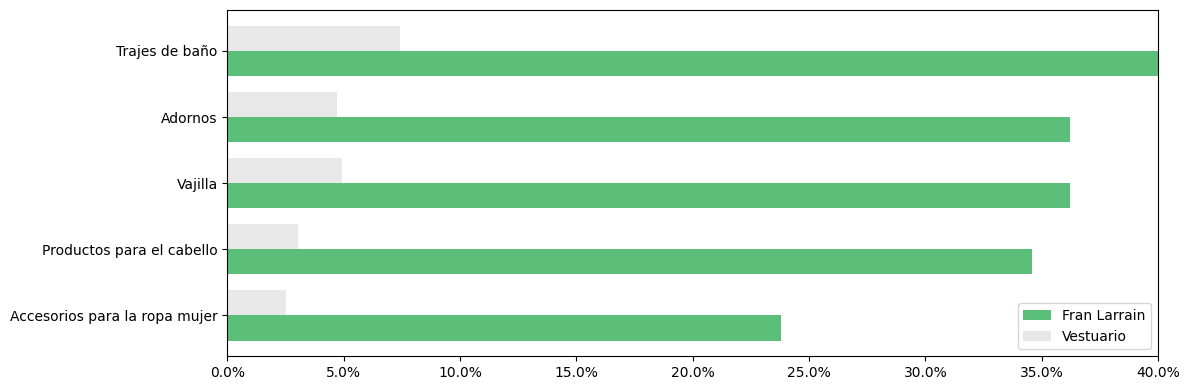

In [29]:
df_plot = df_lift.sort_values("Campanha", ascending=False)  
cats = df_plot["Categoria"].tolist()
camp = df_plot["Campanha"].astype(float).values
base = df_plot["Vestuario"].astype(float).values

y = np.arange(len(cats))
h = 0.38  # grosor de cada barra

plt.figure(figsize=(12, 4))

plt.barh(y + h/2, camp, height=h, label=campaing_name, color="#5BBF7A")   # arriba/abajo (al lado)
plt.barh(y - h/2, base, height=h, label=comprative_pool, color="#E8E8E8")

plt.yticks(y, cats)
plt.gca().invert_yaxis()  # el mayor arriba (porque ordenamos asc)

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.xlim(0, 0.4)  
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
sql_lift_brand = f"""
-- marcas (TOP 5 por LIFT y luego ordenados por % Campanha desc)

DECLARE max_date_clm DATE;
DECLARE fecha_analisis_inicio DATE;
DECLARE fecha_analisis_fin DATE;
DECLARE piscina STRING;

SET fecha_analisis_fin    = DATE('{fecha_fin_str}');
SET fecha_analisis_inicio = DATE('{fecha_inicio_str}');
SET piscina = '{comprative_pool}';

SET max_date_clm = (
  SELECT MAX(DATE(PARTITION_DATE))
  FROM `falabella-rtl-segmentation-ai.sia_10_mkt_processes.customer_lifecycle`
  WHERE DATE(PARTITION_DATE) >= DATE_SUB(CURRENT_DATE(), INTERVAL 30 DAY)
  HAVING COUNT(1) > 1
);

WITH
USER_CAMPAINGS AS (
  SELECT DISTINCT
    CUST_RULE_ID AS CUST_ID
  FROM `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified`
  WHERE TRAN_DT BETWEEN fecha_analisis_inicio AND fecha_analisis_fin
    AND PARTITION_DATE BETWEEN fecha_analisis_inicio AND fecha_analisis_fin
    AND VALID_PRODUCT_FLG = TRUE
     AND (STORE_F_FLG = TRUE OR STORE_STAND_ALONE_FLG = TRUE)
    AND INVALID_CUSTOMER_FLG = FALSE
    AND TRAN_TYPE_DESC IN ('VENTA','FACTURA','CAMBIO','DEVOLUCION')
    AND BU_MODEL IN ('3P GSC','3P IMP','1P FALABELLA','3P SVL')
    AND ({dynamic_filter})
),

SOCIODEMO AS (
  SELECT
    CUST_ID,
    COMUNA_DEF,
    RANGO_ETARIO,
    CUST_GENDER
  FROM `falabella-rtl-segmentation-ai.sia_10_mkt_processes.customer_lifecycle`
  WHERE PARTITION_DATE = max_date_clm
),

F_POOL_MAPPER AS (
  SELECT FCATEGORY_2, POOL_NAME
  FROM `falabella-rtl-segmentation-ai.datalake_retail.svw_trf_fal_corp_cat_prd_wrk_product_category_f_pool`
  WHERE LAST_UPDATE_DATE >= '2025-01-01'
  QUALIFY LAST_UPDATE_DATE = MAX(LAST_UPDATE_DATE) OVER (PARTITION BY FCATEGORY_2)
),

J_POOL_MAPPER AS (
  SELECT SUBLINE_ID, POOL_NAME
  FROM `falabella-rtl-segmentation-ai.datalake_retail.svw_trf_fal_corp_cat_prd_wrk_product_category_j_pool`
  WHERE LAST_UPDATE_DATE >= '2025-01-01'
  QUALIFY LAST_UPDATE_DATE = MAX(LAST_UPDATE_DATE) OVER (PARTITION BY SUBLINE_ID)
),

TRANSACTIONS AS (
  SELECT DISTINCT
    T.CUST_RULE_ID AS CUST_ID,
    T.PROD_BRAND_ID,
    COALESCE(F.POOL_NAME, J.POOL_NAME) AS POOL_NAME,
    CASE WHEN SD.CUST_GENDER = "F" THEN 1 ELSE 0 END AS IND_FEM
  FROM `falabella-rtl-segmentation-ai.sia_02_entities.cl_entities_transaction_enriched_unified` T
  LEFT JOIN SOCIODEMO SD
    ON SD.CUST_ID = T.CUST_RULE_ID
  LEFT JOIN F_POOL_MAPPER F
    ON F.FCATEGORY_2 = T.PROD_F_SUB_CAT_ID
  LEFT JOIN J_POOL_MAPPER J
    ON J.SUBLINE_ID = T.PROD_SUB_CAT_ID
  WHERE T.PARTITION_DATE BETWEEN DATE_SUB(fecha_analisis_inicio, INTERVAL 12 MONTH) AND DATE_SUB(fecha_analisis_inicio, INTERVAL 1 DAY)
    AND T.VALID_PRODUCT_FLG = TRUE
),

USER_VESTUARIO AS (
  SELECT DISTINCT CUST_ID
  FROM TRANSACTIONS
  WHERE POOL_NAME = piscina
),

DATA AS (
  SELECT DISTINCT
    CUST_ID,
    PROD_BRAND_ID,
    CASE WHEN UC.CUST_ID IS NOT NULL THEN 1 ELSE 0 END AS USER_CAMPAIGN
  FROM TRANSACTIONS
  INNER JOIN USER_VESTUARIO USING (CUST_ID)
  LEFT JOIN USER_CAMPAINGS UC USING (CUST_ID)
),

BRAND_PERCENTAGE AS (
  SELECT
    PROD_BRAND_ID,
    COUNT(DISTINCT CUST_ID) AS N_LOCALITY_BASELINE,
    (SELECT COUNT(DISTINCT CUST_ID) FROM DATA) AS N_BASELINE_TOTAL,
    COUNT(DISTINCT CUST_ID) / (SELECT COUNT(DISTINCT CUST_ID) FROM DATA) AS BASELINE_PERCENTAGE
  FROM DATA
  GROUP BY PROD_BRAND_ID
),

CAMPAIGN_PERCENTAGE AS (
  SELECT
    PROD_BRAND_ID,
    COUNT(DISTINCT CUST_ID) / (SELECT COUNT(DISTINCT CUST_ID) FROM DATA WHERE USER_CAMPAIGN = 1) AS PERCENTAGE,
    (SELECT COUNT(DISTINCT CUST_ID) FROM DATA WHERE USER_CAMPAIGN = 1) AS N_CAMPAIGN_TOTAL,
    COUNT(DISTINCT CUST_ID) AS N_USER_CAMPAIGN
  FROM DATA
  WHERE USER_CAMPAIGN = 1
  GROUP BY PROD_BRAND_ID
),

BASE AS (
  SELECT
    CASE WHEN PROD_BRAND_ID = "FALABELLA" THEN "ROPERO PAULA" ELSE PROD_BRAND_ID END AS PROD_BRAND_ID,
    N_USER_CAMPAIGN,
    N_CAMPAIGN_TOTAL,
    PERCENTAGE,
    N_LOCALITY_BASELINE,
    N_BASELINE_TOTAL,
    BASELINE_PERCENTAGE,
    SAFE_DIVIDE(PERCENTAGE, BASELINE_PERCENTAGE) AS LIFT,
    CASE
      WHEN N_USER_CAMPAIGN * PERCENTAGE > 5
       AND N_USER_CAMPAIGN * (1 - PERCENTAGE) > 5
      THEN 1 ELSE 0
    END AS COMPARABLE
  FROM CAMPAIGN_PERCENTAGE
  LEFT JOIN BRAND_PERCENTAGE USING (PROD_BRAND_ID)
  WHERE PROD_BRAND_ID IS NOT NULL
    AND N_USER_CAMPAIGN >= (SELECT COUNT(DISTINCT CUST_ID)/10 FROM USER_CAMPAINGS)
    AND (CASE
      WHEN N_USER_CAMPAIGN * PERCENTAGE > 5
       AND N_USER_CAMPAIGN * (1 - PERCENTAGE) > 5
      THEN 1 ELSE 0 END) = 1
),

TOP5_LIFT AS (
  SELECT *
  FROM BASE
  WHERE COMPARABLE = 1
  ORDER BY LIFT DESC
  LIMIT 5
)

SELECT
  PROD_BRAND_ID AS Marca,
  PERCENTAGE AS Campanha,
  BASELINE_PERCENTAGE AS Vestuario,
  LIFT
FROM TOP5_LIFT
ORDER BY Campanha DESC;
"""

#### Grafico Lift Brand

In [31]:
df_lift_brand = client.query(sql_lift_brand).to_dataframe()

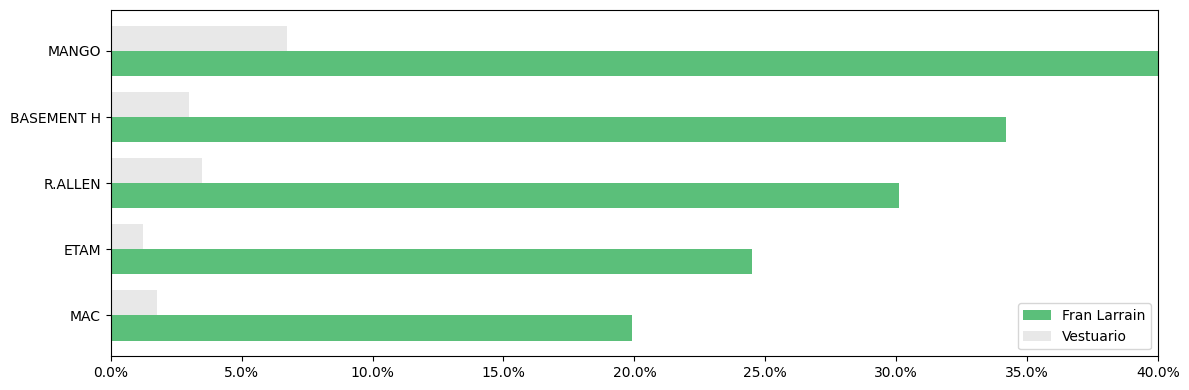

In [32]:
df_plot = df_lift_brand.sort_values("Campanha", ascending=False)  
cats = df_plot["Marca"].tolist()
camp = df_plot["Campanha"].astype(float).values
base = df_plot["Vestuario"].astype(float).values

y = np.arange(len(cats))
h = 0.38  # grosor de cada barra

plt.figure(figsize=(12, 4))

plt.barh(y + h/2, camp, height=h, label=campaing_name, color="#5BBF7A")   # arriba/abajo (al lado)
plt.barh(y - h/2, base, height=h, label=comprative_pool, color="#E8E8E8")

plt.yticks(y, cats)
plt.gca().invert_yaxis()  # el mayor arriba (porque ordenamos asc)

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.xlim(0, 0.4)  
plt.legend()
plt.tight_layout()
plt.show()

### Navegacion

In [33]:
sql_nav = f"""
with

base as (
select 
  partition_date
  , visit_id
  , page_url

from (select 
    partition_date
    , visit_id
    , date_time
    , visit_page_num
    , page_name
    , page_url
      FROM 	`txd-fal-corp-3p-acc-wbx.acc_fal_cl_nav.svw_bi_fcom_drmb_sharing_hub_sbx_svw_acc_fcm_cl_mktg_weba_v3_bu_prd_svw_svw_btd_v3_optin_clickstream` 
      WHERE partition_date BETWEEN '{fecha_inicio_str}' AND '{fecha_fin_str}'
       
          AND NOT (app_id IS NOT NULL
                  AND (app_section IN ('rc_update', 'deep_linking') OR app_section IS NULL)
                  AND visit_page_num  <= 5)
          AND page_load IS NOT NULL
  )
group by all

)

select
  partition_date as fecha
  ,count(distinct visit_id) as visitas

  from base
  where (page_url) like '%{url_navegacion}%'

  group by all
  order by 1 asc
"""

In [34]:
print(sql_nav)


with

base as (
select 
  partition_date
  , visit_id
  , page_url

from (select 
    partition_date
    , visit_id
    , date_time
    , visit_page_num
    , page_name
    , page_url
      FROM 	`txd-fal-corp-3p-acc-wbx.acc_fal_cl_nav.svw_bi_fcom_drmb_sharing_hub_sbx_svw_acc_fcm_cl_mktg_weba_v3_bu_prd_svw_svw_btd_v3_optin_clickstream` 
      WHERE partition_date BETWEEN '2026-05-19' AND '2026-05-24'
       
          AND NOT (app_id IS NOT NULL
                  AND (app_section IN ('rc_update', 'deep_linking') OR app_section IS NULL)
                  AND visit_page_num  <= 5)
          AND page_load IS NOT NULL
  )
group by all

)

select
  partition_date as fecha
  ,count(distinct visit_id) as visitas

  from base
  where (page_url) like '%collection/franlarrain%'

  group by all
  order by 1 asc



In [35]:
df_nav = client.query(sql_nav).to_dataframe()

In [36]:
df_nav.head(10)

,fecha,visitas
0,2026-05-19,7583
1,2026-05-20,14095
2,2026-05-21,11716


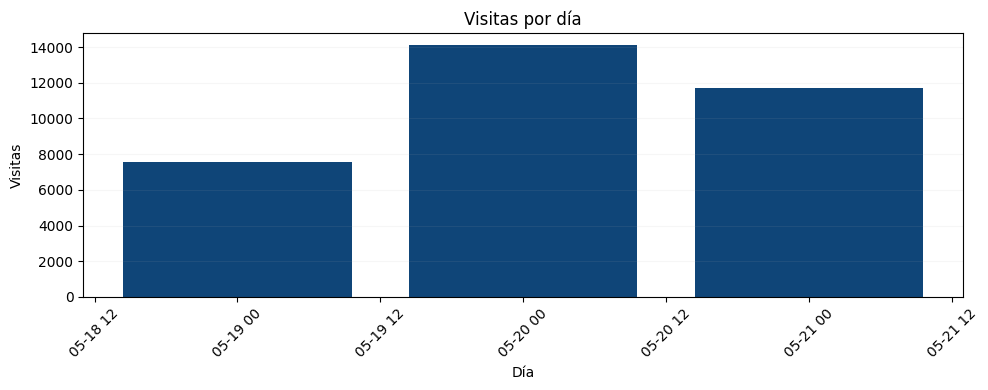

In [37]:
plt.figure(figsize=(10, 4))
blue = "#0F4578"
plt.bar(
    df_nav["fecha"],
    df_nav["visitas"],
    color=blue
)

plt.xlabel("Día")
plt.ylabel("Visitas")
plt.title("Visitas por día")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.1)
plt.tight_layout()
plt.show()

### output JSON

In [38]:
# ============================================================
# OUTPUT JSON — Perfil de Campaña
# ============================================================
import json
from datetime import datetime

# ---- helpers ----
MESES_ES = {1:'ene',2:'feb',3:'mar',4:'abr',5:'may',6:'jun',
            7:'jul',8:'ago',9:'sep',10:'oct',11:'nov',12:'dic'}

def fmt_fecha(dt):
    """datetime → '7 abr' """
    return f"{dt.day} {MESES_ES[dt.month]}"

def fmt_periodo(ini, fin):
    """'2026-04-07' '2026-05-02' → '07 abr — 02 may 2026' """
    d0 = datetime.strptime(ini, "%Y-%m-%d")
    d1 = datetime.strptime(fin, "%Y-%m-%d")
    return f"{d0.day:02d} {MESES_ES[d0.month]} — {d1.day:02d} {MESES_ES[d1.month]} {d1.year}"

def pct(val, decimals=1):
    """0.561 → 56.1 """
    return round(float(val) * 100, decimals)

def badge_from_url(url):
    """'collection/zapatillas-running' → 'Zapatillas Running' """
    slug = url.rstrip("/").split("/")[-1]
    return slug.replace("-", " ").title()

# ---- filas camp / comp ----
camp = df_perfil[df_perfil["cat"].str.lower().str.contains("camp")].iloc[0]
comp = df_perfil[df_perfil["cat"].str.lower().str.contains("comp")].iloc[0]

# ---- venta diaria ----
df_venta_canal["fecha"] = pd.to_datetime(df_venta_canal["fecha"])
for col in ["FCOM", "TIENDA"]:
    if col not in df_venta_canal.columns:
        df_venta_canal[col] = 0
df_venta_canal = df_venta_canal.sort_values("fecha")

diaria = [
    {
        "f":      fmt_fecha(row["fecha"]),
        "fcom":   int(row["FCOM"]),
        "tienda": int(row["TIENDA"])
    }
    for _, row in df_venta_canal.iterrows()
]

fcom_total   = int(df_venta_canal["FCOM"].sum())
tienda_total = int(df_venta_canal["TIENDA"].sum())
venta_total  = fcom_total + tienda_total

# ---- JSON final ----
output = {
    "meta": {
        "title":    campaing_name,
        "subtitle": "MKT Directo · Falabella",
        "badge":    badge_from_url(url_navegacion)
    },
    "venta": {
        "total":   venta_total,
        "periodo": fmt_periodo(fecha_inicio_str, fecha_fin_str),
        "fcom":    fcom_total,
        "tienda":  tienda_total,
        "diaria":  diaria
    },
    "kpis": {
        "clientes_camp":   int(camp["clientes"]),
        "clientes_comp":   int(comp["clientes"]),
        "gasto_camp":      int(round(camp["Gasto_cliente"])),
        "gasto_comp":      int(round(comp["Gasto_cliente"])),
        "frecuencia_camp": round(float(camp["Freq_compra"]), 3),
        "frecuencia_comp": round(float(comp["Freq_compra"]), 3),
        "ticket_camp":     int(round(camp["ticket_promedio"])),
        "ticket_comp":     int(round(comp["ticket_promedio"]))
    },
    "genero": [
        {"id": "f", "l": "Mujeres", "c": pct(camp["Mujeres"]), "k": pct(comp["Mujeres"])},
        {"id": "m", "l": "Hombres", "c": pct(camp["Hombres"]), "k": pct(comp["Hombres"])}
    ],
    "edad": [
        {"l": "18–25",    "c": pct(camp["cltes_18_25"]), "k": pct(comp["cltes_18_25"])},
        {"l": "26–35",    "c": pct(camp["cltes_25_35"]), "k": pct(comp["cltes_25_35"])},
        {"l": "36–45",    "c": pct(camp["cltes_35_45"]), "k": pct(comp["cltes_35_45"])},
        {"l": "46–55",    "c": pct(camp["cltes_45_55"]), "k": pct(comp["cltes_45_55"])},
        {"l": "56 o más", "c": pct(camp["cltes_55_99"]), "k": pct(comp["cltes_55_99"])}
    ],
    "gse": [
        {"l": "ABC1", "c": pct(camp["cltes_ABC1"]), "k": pct(comp["cltes_ABC1"])},
        {"l": "C2",   "c": pct(camp["cltes_C2"]),   "k": pct(comp["cltes_C2"])},
        {"l": "C3",   "c": pct(camp["cltes_C3"]),   "k": pct(comp["cltes_C3"])},
        {"l": "D",    "c": pct(camp["cltes_D"]),    "k": pct(comp["cltes_D"])},
        {"l": "E",    "c": pct(camp["cltes_E"]),    "k": pct(comp["cltes_E"])}
    ],
    "tipo": [
        {"l": "Clientes F",  "c": pct(camp["cltes_f"]),          "k": pct(comp["cltes_f"])},
        {"l": "Nuevos Fal.", "c": pct(camp["cltes_nuevos_fal"]), "k": pct(comp["cltes_nuevos_fal"])}
    ],
    "zonas": [
        {"l": "Norte",    "c": pct(camp["cltes_norte"]),    "k": pct(comp["cltes_norte"])},
        {"l": "Sur",      "c": pct(camp["cltes_sur"]),      "k": pct(comp["cltes_sur"])},
        {"l": "Poniente", "c": pct(camp["cltes_poniente"]), "k": pct(comp["cltes_poniente"])},
        {"l": "Oriente",  "c": pct(camp["cltes_oriente"]),  "k": pct(comp["cltes_oriente"])}
    ]
}

print(json.dumps(output, ensure_ascii=False, indent=2))


{
  "meta": {
    "title": "Fran Larrain",
    "subtitle": "MKT Directo · Falabella",
    "badge": "Franlarrain"
  },
  "venta": {
    "total": 19506002,
    "periodo": "19 may — 24 may 2026",
    "fcom": 13874788,
    "tienda": 5631214,
    "diaria": [
      {
        "f": "19 may",
        "fcom": 2974608,
        "tienda": 1153842
      },
      {
        "f": "20 may",
        "fcom": 6780124,
        "tienda": 1952730
      },
      {
        "f": "21 may",
        "fcom": 4120056,
        "tienda": 2524642
      }
    ]
  },
  "kpis": {
    "clientes_camp": 189,
    "clientes_comp": 6162,
    "gasto_camp": 99397,
    "gasto_comp": 42593,
    "frecuencia_camp": 1.021,
    "frecuencia_comp": 1.01,
    "ticket_camp": 97337,
    "ticket_comp": 42168
  },
  "genero": [
    {
      "id": "f",
      "l": "Mujeres",
      "c": 93.1,
      "k": 87.6
    },
    {
      "id": "m",
      "l": "Hombres",
      "c": 6.9,
      "k": 12.4
    }
  ],
  "edad": [
    {
      "l": "18–25",
      "c